# Продвинутый анализ моделей


|раздел | [nixtla](https://nixtlaverse.nixtla.io/statsforecast/) | [FPPPY](https://otexts.com/fpppy/)|
|-------|-----------------------|------|
|аугментация |     -    | [13.6](https://otexts.com/fpppy/nbs/13-practical.html#sec-backcasting)   |
|ансамбли моделей | - | [13.4](https://otexts.com/fpppy/nbs/13-practical.html#sec-combinations) |
|учет нерегулярных данных| [Anomaly Det](https://nixtlaverse.nixtla.io/statsforecast/docs/tutorials/anomalydetection.html) [GitHub](https://github.com/Nixtla/statsforecast/blob/main/nbs/docs/tutorials/AnomalyDetection.ipynb) | [13.8](https://otexts.com/fpppy/nbs/13-practical.html#sec-missing-outliers) |


* [Python implementations of time series forecasting and anomaly detection](https://robjhyndman.com/hyndsight/python_time_series.html)
* [Using Nixtla to do anomaly detection](https://github.com/PieroPaialungaAI/AnomalyDetectionNixtla/blob/main/Anomaly_Calibration_Notebook.ipynb) / [Performance Evaluation of Anomaly Detection through Synthetic Anomalies](https://www.nixtla.io/blog/anomaly-detection-performance-evaluation)
* 

## Импорт

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [2]:
from statsforecast import StatsForecast
from statsforecast.models import *

from utilsforecast.plotting import plot_series
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import *

In [3]:
from scipy import stats
import pmdarima as pm

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan
from statsmodels.tsa.stattools import kpss

import statsmodels.api as sm

In [4]:
from pandas.tseries.frequencies import to_offset

In [5]:
from TSC_Nixtla_dump import *
plt_style_GOST()

In [6]:
from TSC_Nixtla_augmentation import *

In [7]:
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.simplefilter('ignore', ConvergenceWarning)
warnings.simplefilter("ignore", FutureWarning)

from statsmodels.tools.sm_exceptions import InterpolationWarning
warnings.filterwarnings("ignore", category=InterpolationWarning)

In [8]:
from functools import partial

## Загрузка данных

Импорт данных аналогично предыдущего урока.

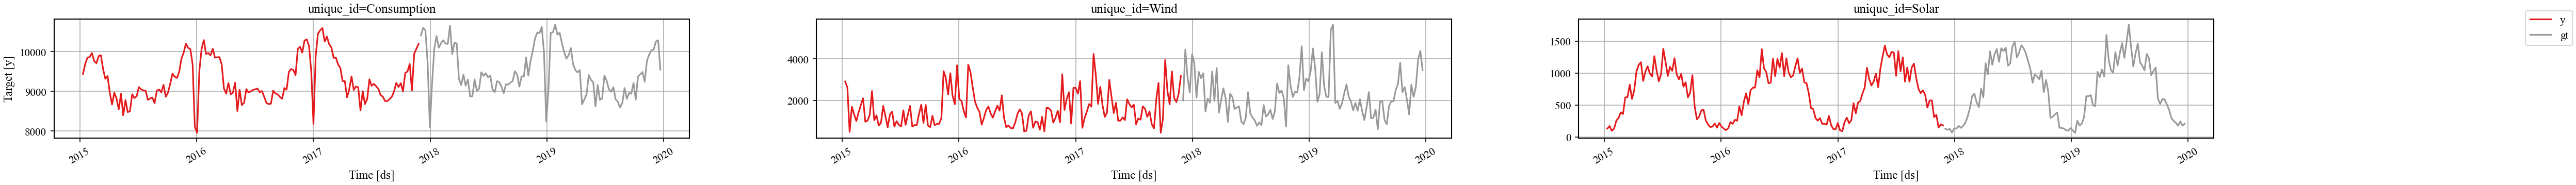

In [9]:
df= pd.read_csv(
    "OPDS_DE_EDA.csv",
    parse_dates=["time"],
    index_col="time"
)
df.head(1)
ts = ['Consumption','Wind',	'Solar']
exog_cols = ['temperature','radiation_direct_horizontal']
y = df.resample('W').agg({
    'Consumption': 'sum',
    'Wind': 'sum',
    'Solar': 'sum',
    'temperature': 'mean',
    'radiation_direct_horizontal': 'mean'
}).ffill().bfill() + 1e-8

y = y.iloc[1:-2]



ts = ['Consumption', 'Wind', 'Solar']
base_cols = ['unique_id', 'ds', 'y']

date_index = y.index
panel_list = [pd.DataFrame({'ds':date_index , 'y': y[t].values, 'unique_id': t}) for t in ts]
panel_df = pd.concat(panel_list, ignore_index=True)
panel_df = panel_df[base_cols] #порядок колонок
panel_df.sample(5)

FREQ = y.index.freq


SEASON = 52

FH = int(0.42 * y.shape[0])

df_test  = panel_df[base_cols].groupby("unique_id").tail(FH)
df_train = panel_df[base_cols].drop(df_test.index).reset_index(drop=True)

plot_series_v2(df_train, df_test.rename(columns={"y": "gt"}),  palette='Set1', n_cols = 3)

In [10]:
metric_map = {
    'mase': partial(mase, seasonality=SEASON),
    'mae': mae,
    'rmse': rmse,
    'smape': smape,
    'CPSR':scaled_crps,
    'CI':coverage,
    'SQL':partial(scaled_quantile_loss, seasonality=SEASON),
}
metrics = list(metric_map.values())
metric_names = list(metric_map.keys())

## Некоторые приемы аугментации данных

### Backcasting

In [11]:
BH = 3*SEASON
LEVEL = [90]
models = [
    ARIMA(order=(2, 1, 1), season_length=SEASON, seasonal_order=(0, 1, 1))
]

df_train_extended = backcast(
    df_train=df_train,
    models=models,
    h=BH,
    freq=FREQ,
    level=LEVEL
)

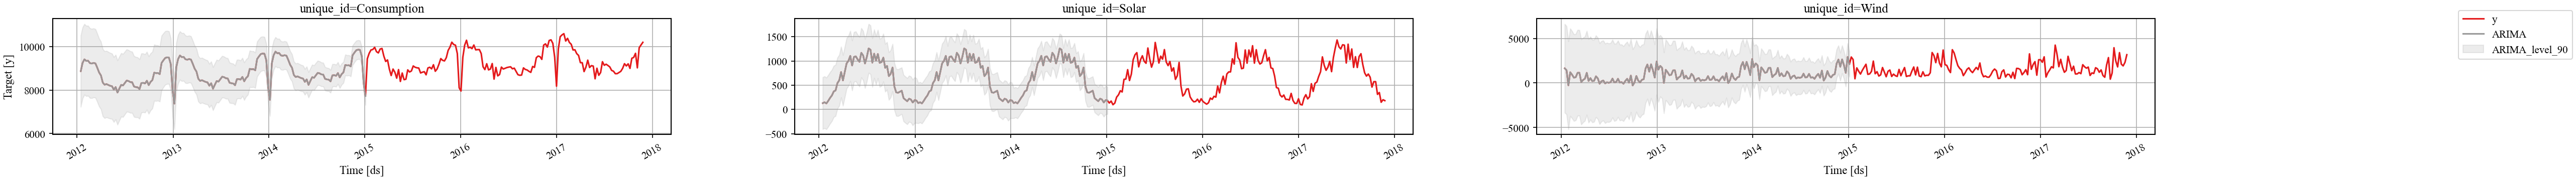

In [12]:
plot_series_v2( forecasts_df=df_train_extended, level=LEVEL[-1:],  palette='Set1', n_cols = 3)

#### Оценка эффективности ипсользования `backcast`

##### С расширением  `backcast`

In [13]:
models = [
    AutoETS(season_length=SEASON, model='ZZA', damped = False, alias='ETS'),
    # MSTL(season_length=SEASON, ),
    # TBATS(SEASON, use_trend = True, use_damped_trend = True),   
]
aliases = [model.alias for model in models]
LEVELS = [90]

sf = StatsForecast(
    models=models,
    freq=FREQ,   
)


In [14]:
fcst_sf = sf.forecast(df=df_train_extended, h=FH, level=LEVELS,)
eval_sf = df_test.merge(fcst_sf, on=['unique_id', 'ds'])

metrics_sf_models = evaluate(
    df=eval_sf,
    metrics=metrics,
    train_df=df_train_extended,
    level=LEVELS[:],
).pivot(
    index='metric',
    columns='unique_id',
    values=aliases
)
metrics_sf_models = pd.concat({'with_backcast': metrics_sf_models}, axis=1)
metrics_sf_models.style.format('{:.2f}')

##### Без расширения

In [15]:
fcst_sf = sf.forecast(df=df_train, h=FH, level=LEVELS,)
eval_sf = df_test.merge(fcst_sf, on=['unique_id', 'ds'])

metrics_sf_models_ = evaluate(
    df=eval_sf,
    metrics=metrics,
    train_df=df_train,
    level=LEVELS[:],
).pivot(
    index='metric',
    columns='unique_id',
    values=aliases
)

##### Сравним 2 модели по метрикам

In [16]:
metrics_sf_models_ = pd.concat({'GT': metrics_sf_models_}, axis=1)

metrics_sf_models = pd.concat([metrics_sf_models_, metrics_sf_models], axis=1)

metrics_sf_models.style.format('{:.2f}')

Результаты показывают некоторое снижение точеченых метрик при увеличении неопределенности прогноза. Хотя, при этом 95 и 5 хвосты предсказываются чуть лучше. coverage_level90 показывает ухудшение оценки интервалов.

### Провека корректности аугментации
#### Сравнения маргинальных распределений

Проверка адекватности аугментации начинается с сравнения маргинальных распределений исходного и синтетического рядов (без учета времени): если они статистически близки, аугментация не искажает базовые свойства данных.

* __нормализованное Wasserstein distance__ - сводная статистика, учиюывающая  форму, и сдвиг, измеряется в тех же единицах, что и данные.  Нормализация проводится к СКО. Интерпретация, если различия распределений сопостовимы с СКО, то имеют место существенные систематическом изменения в распределениях. 
* __KS statistic__ — сводная статистика Калмогорова-Смирнова для 2 двух распределений, учиюывающая максимальную (локальную) разницу параметров в гистограммах двух распределений. 
* __относительня mean_diff_pct__  — показывает смещение центра распределения (систематическое смещение).
* ____относительня std_diff_pct__ — показывает изменение разброса данных (систематическое изменение разброса данных).

Отметим, что лучше проводить тесты после учета тренда и сезонности.

In [17]:
n_backcast = len(df_train_extended) - len(df_train)
result = marginal_distribution_test(df_train['y'].values, df_train_extended.iloc[:n_backcast]['y'].values, name="backcasting")
result

,augmentation,metric,value,threshold,passed
0,backcasting,wasserstein,0.5901,0.1500,0
1,backcasting,ks_pvalue,0.0000,0.0500,0
2,backcasting,mean_diff_pct,59.4731,5.0000,0
3,backcasting,std_diff_pct,2.6514,10.0000,1


Результаты показывают что модель беккастинга воспроизводит только СКО оригинального ряда

#### Сравнение остатков

Отметим, что лучше проводить тесты после учета тренда и сезонности.

In [18]:
from statsforecast.feature_engineering import mstl_decomposition


mstl_model =  MSTL(season_length=[SEASON])

transformed_df, _ = mstl_decomposition(
    df_train,
    model=mstl_model,
    freq=FREQ,
    h=1  # h=0 если только хотим декомпозицию
)
transformed_df['residual'] = transformed_df['y']  - transformed_df['trend'] - transformed_df['seasonal'] 


transformed_df_extend, _ = mstl_decomposition(
    df_train_extended,
    model=mstl_model,
    freq=FREQ,
    h=1  # h=0 если только хотим декомпозицию
)
transformed_df_extend['residual'] = transformed_df_extend['y']  - transformed_df_extend['trend'] - transformed_df_extend['seasonal'] 

n_backcast = len(transformed_df_extend) - len(transformed_df)
result = marginal_distribution_test(transformed_df['residual'].values, transformed_df_extend.iloc[:n_backcast]['residual'].values, name="backcasting")
result

,augmentation,metric,value,threshold,passed
0,backcasting,wasserstein,0.4981,0.1500,0
1,backcasting,ks_pvalue,0.0000,0.0500,0
2,backcasting,mean_diff_pct,329.3914,5.0000,0
3,backcasting,std_diff_pct,72.9276,10.0000,0


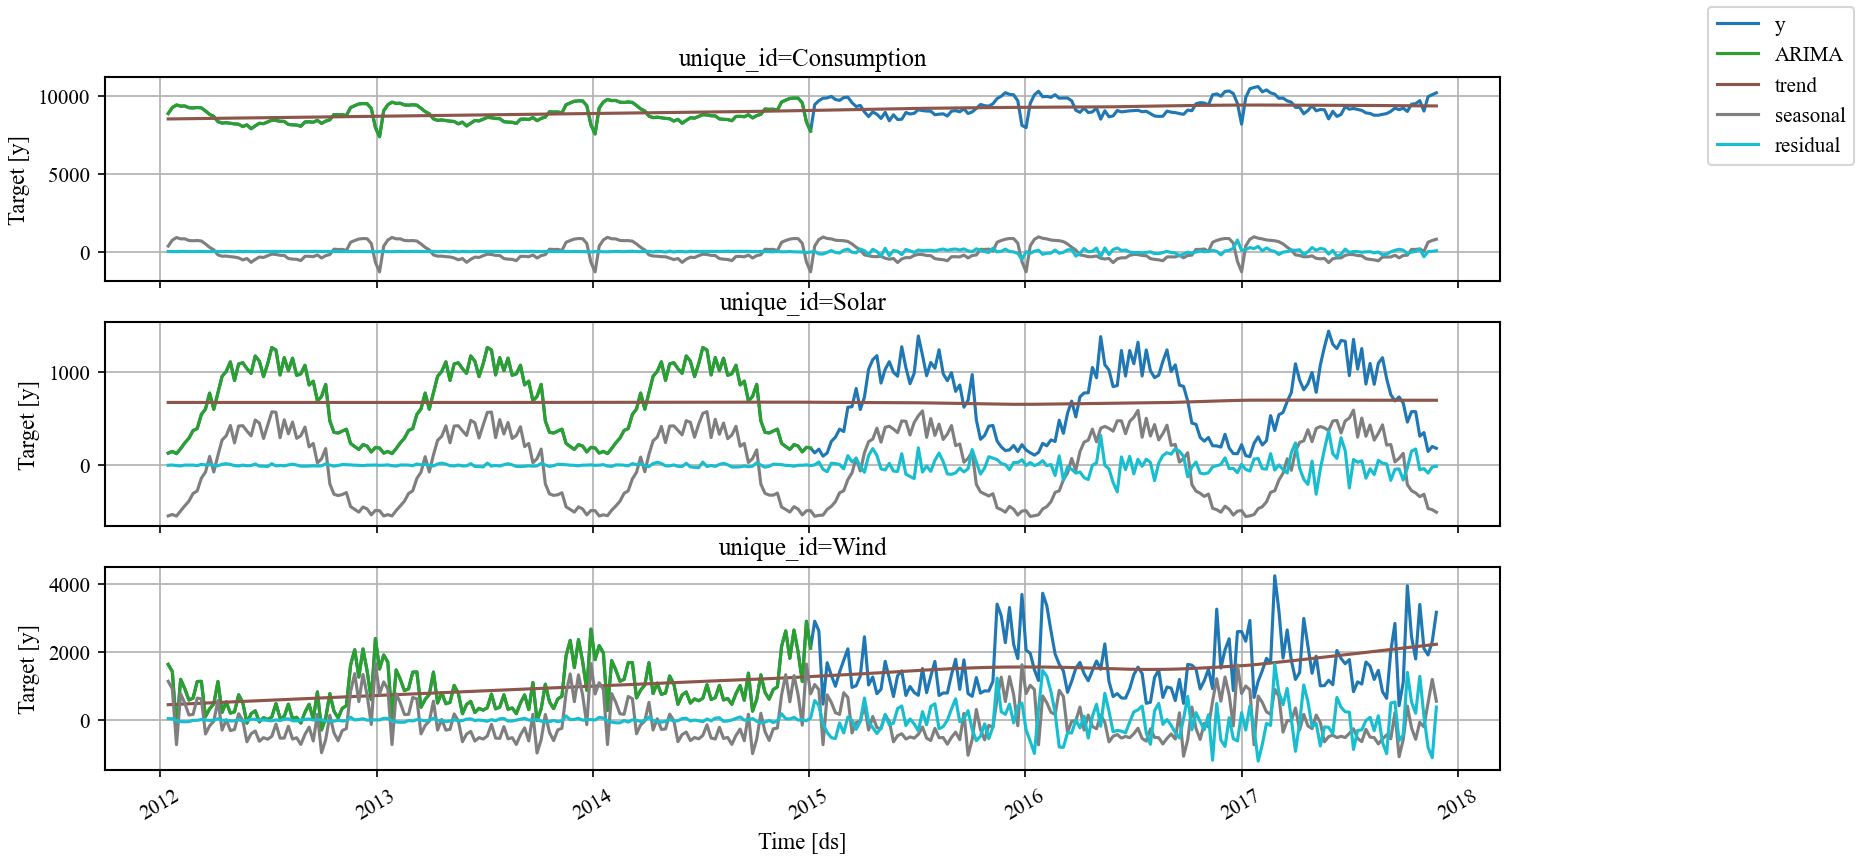

In [19]:
plot_series_v2(forecasts_df=transformed_df_extend)

Видно, что действительно тренд и остатки поменял форм.

#### Структурные тесты

Также проведем тесты 

* __ACF MAE__  — средняя ошибка между ACF оригинала и аугментации (проверяет сохранение временной структуры).
* __Spectral distance__ — расстояние Вассерштейна между спектрами мощности (проверяет сезонность).
* __Quantile coverage__  — сохаранение значений покрытия ключевых квантилей (10%, 50%, 90%).
* __Volatility correlation__ — корреляция скользящего стандартного отклонения (проверяет кластеризацию волатильности).

In [20]:
n_backcast = len(df_train_extended) - len(df_train)
result = structural_tests(df_train['y'].values, df_train_extended.iloc[:n_backcast]['y'].values, name="backcasting")
result

,augmentation,metric,value,threshold,passed
0,backcasting,acf_mae,0.0087,0.0500,1
1,backcasting,spectral_dist,0.0017,0.2000,1
2,backcasting,quantile_max_diff,1.8127,0.1500,0
3,backcasting,volatility_corr,0.1937,0.7000,0


In [21]:
n_backcast = len(df_train_extended) - len(df_train)
result = structural_tests(transformed_df['residual'].values, transformed_df_extend.iloc[:n_backcast]['residual'].values, name="backcasting")
result

,augmentation,metric,value,threshold,passed
0,backcasting,acf_mae,0.0878,0.0500,0
1,backcasting,spectral_dist,0.0453,0.2000,1
2,backcasting,quantile_max_diff,0.8187,0.1500,0
3,backcasting,volatility_corr,-0.4687,0.7000,0


Видно сохранение сезонной составляющей (ACF  и spectral_dist для обоих ВР), однако ни покрытие интервалов, ни гетероскедастичность не сохраняются

#### Упражение 
1. провести настройку  и  сравнение  различных методов для backcasting и их виляния на метрики
2. Провести анализ остатков предсказания с беккастингом и без него
3. Проведите backtesing (CV) с backcasting и без

### Стресс-тесты / аугментация искажениями

#### Примеры искажений

Кроме расширения выборки также может быть использована аугментация путем искажений - создания искусственных нерегулярностей в данных.

Примеры приведены ниже

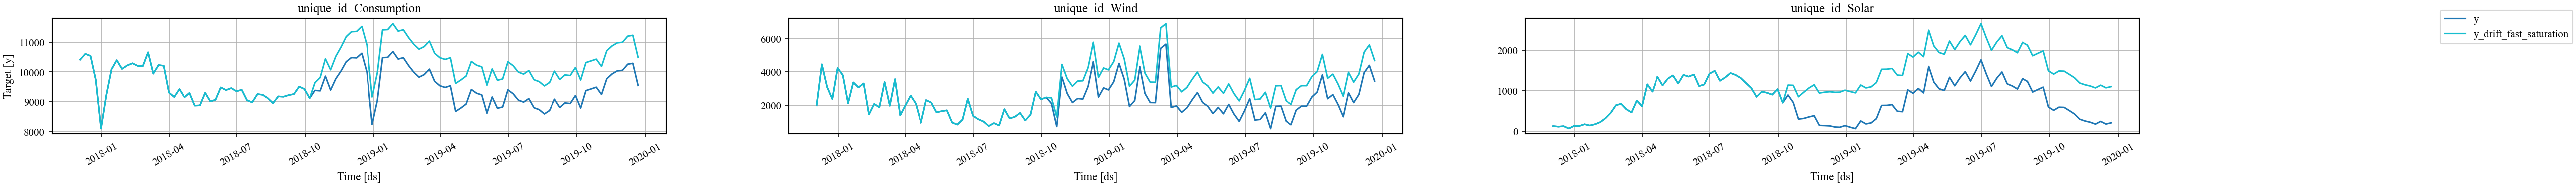

In [22]:
df_structural_shift = add_structural_shift_by_iqr(
    df_test.copy(), 
    start_date='2018-10-01', 
    shift_percent=100, 
    strategy='fast_saturation', 
    duration_offset='26W',
    freq=FREQ
)

plot_series_v2(forecasts_df=df_structural_shift, n_cols = 3)

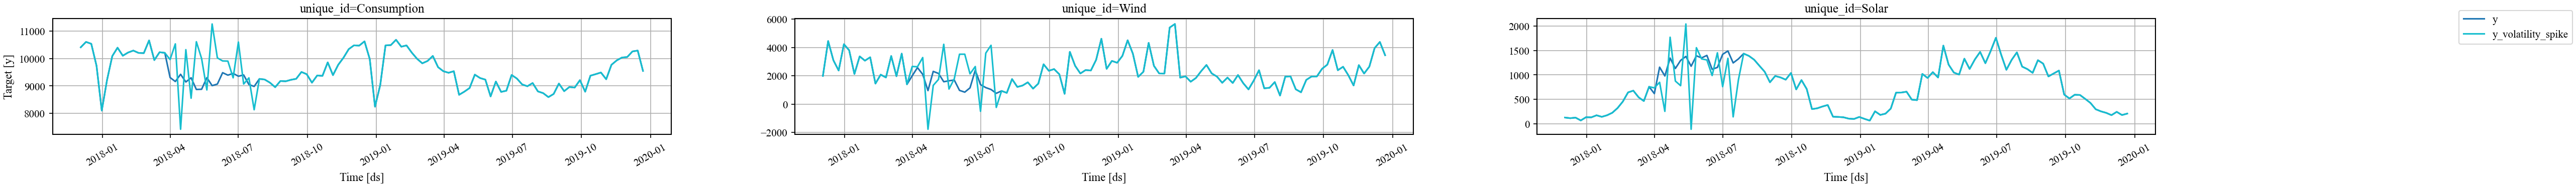

In [23]:
df_spike = add_local_volatility_spike(
    df_test,
    spike_start='2018-04-01',
    duration_offset='16W',
    noise_percent=50.0,
    freq=FREQ
)

plot_series_v2(forecasts_df=df_spike, n_cols = 3)

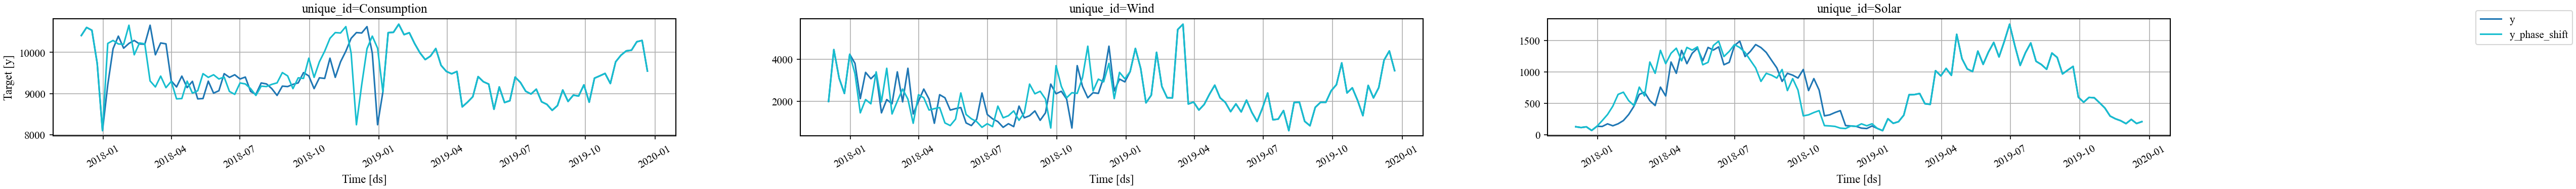

In [24]:
df_seasonal_shift = add_seasonal_phase_shift(
    df_test,
    phase_shift_steps=4,
    season_length=SEASON,          # используется только для документации
    start_date='2018-01-01',
    duration_offset='1Y',
    freq=FREQ
)

plot_series_v2( forecasts_df=df_seasonal_shift, n_cols = 3)

#### Оценка с искажениями

In [25]:
fcst_sf = sf.forecast(df=df_train, h=FH, level=LEVELS,)

eval_sf = df_spike.merge(fcst_sf, on=['unique_id', 'ds'])
eval_sf['y'] = eval_sf['y_volatility_spike']
metrics_sf_models_ = evaluate(
    df=eval_sf,
    metrics=metrics,
    models = ['ETS'],
    train_df=df_train,
    level=LEVELS[:],
).pivot(
    index='metric',
    columns='unique_id',
    values=aliases
)
metrics_sf_models_ = pd.concat({'seasonal_shift': metrics_sf_models_}, axis=1)

eval_sf = df_test.merge(fcst_sf, on=['unique_id', 'ds'])
metrics_sf_models = evaluate(
    df=eval_sf,
    metrics=metrics,
    models = ['ETS'],
    train_df=df_train,
    level=LEVELS[:],
).pivot(
    index='metric',
    columns='unique_id',
    values=aliases
)

metrics_sf_models = pd.concat({'GT': metrics_sf_models}, axis=1)
metrics_sf_models = pd.concat([metrics_sf_models, metrics_sf_models_], axis=1)
metrics_sf_models.style.format('{:.2f}')


- Consumption и Solar стали менее надёжными в оценке неопределённости, особенно на хвостах распределения.
- Wind значительно устойчивей остальных  — возможно, делов в присущей значительно волатильности параметра.
- Модели чувствительны к фазовому сдвигу сезонности — особенно ETS, который явно полагается на жёсткую сезонную структуру.

#### Упражнения №1
1. проверить разные комибнации аугменатций
2. проверить точность с комформным преобразованием
3. проверить точность с бектестинг

#### Упражнения №2 
1. Проверить влияние эффектов аугментации для ВР с шагом в 1 день.

## Тюнинг моделей

### Ансамблирование моделей

#### Выбор моделей для ансамбля

 модели со встроенной оценкой неопределенности

In [26]:
models = [
    AutoETS(season_length=SEASON, model='ZZA', damped = False, alias='ETS'),
    AutoETS(season_length=SEASON, model='MNA', damped = False, alias='SesSES'),
    MSTL(season_length=SEASON, ),
    # TBATS(SEASON, use_trend = True, use_damped_trend = True),
    # ARIMA(order=(3, 1, 1),season_length = SEASON, seasonal_order = (0, 1, 1,)  )    
]
aliases = [model.alias for model in models]
LEVELS  = [90, 95]

sf = StatsForecast(
    models=models,
    freq=FREQ,
)

проверка работы моделей по отдельности

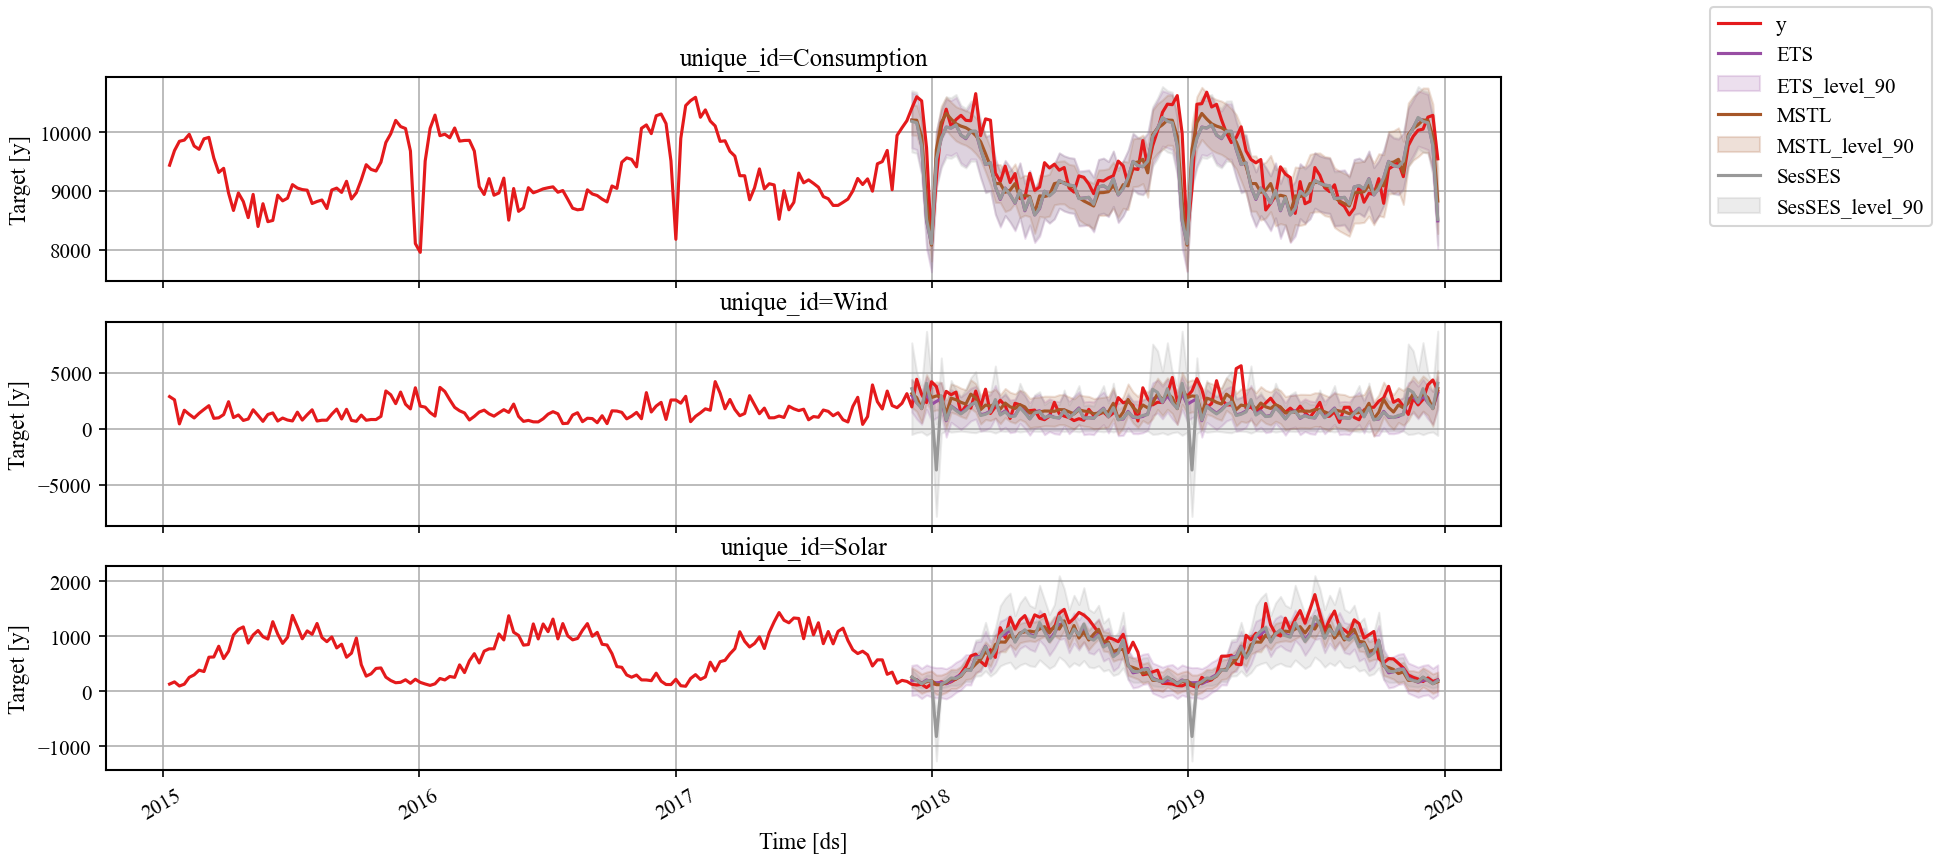

In [27]:
fcst_sf = sf.forecast(df=df_train, 
                      h=FH, 
                      level=LEVELS
                     )
evaluate_and_plot(df_train,
                  df_test,
                  forecasts_or_eval = fcst_sf,
                  metrics = metrics,
                  levels=LEVELS[:1],)


####  Навиный Анcамбль
##### Ансамбль средних

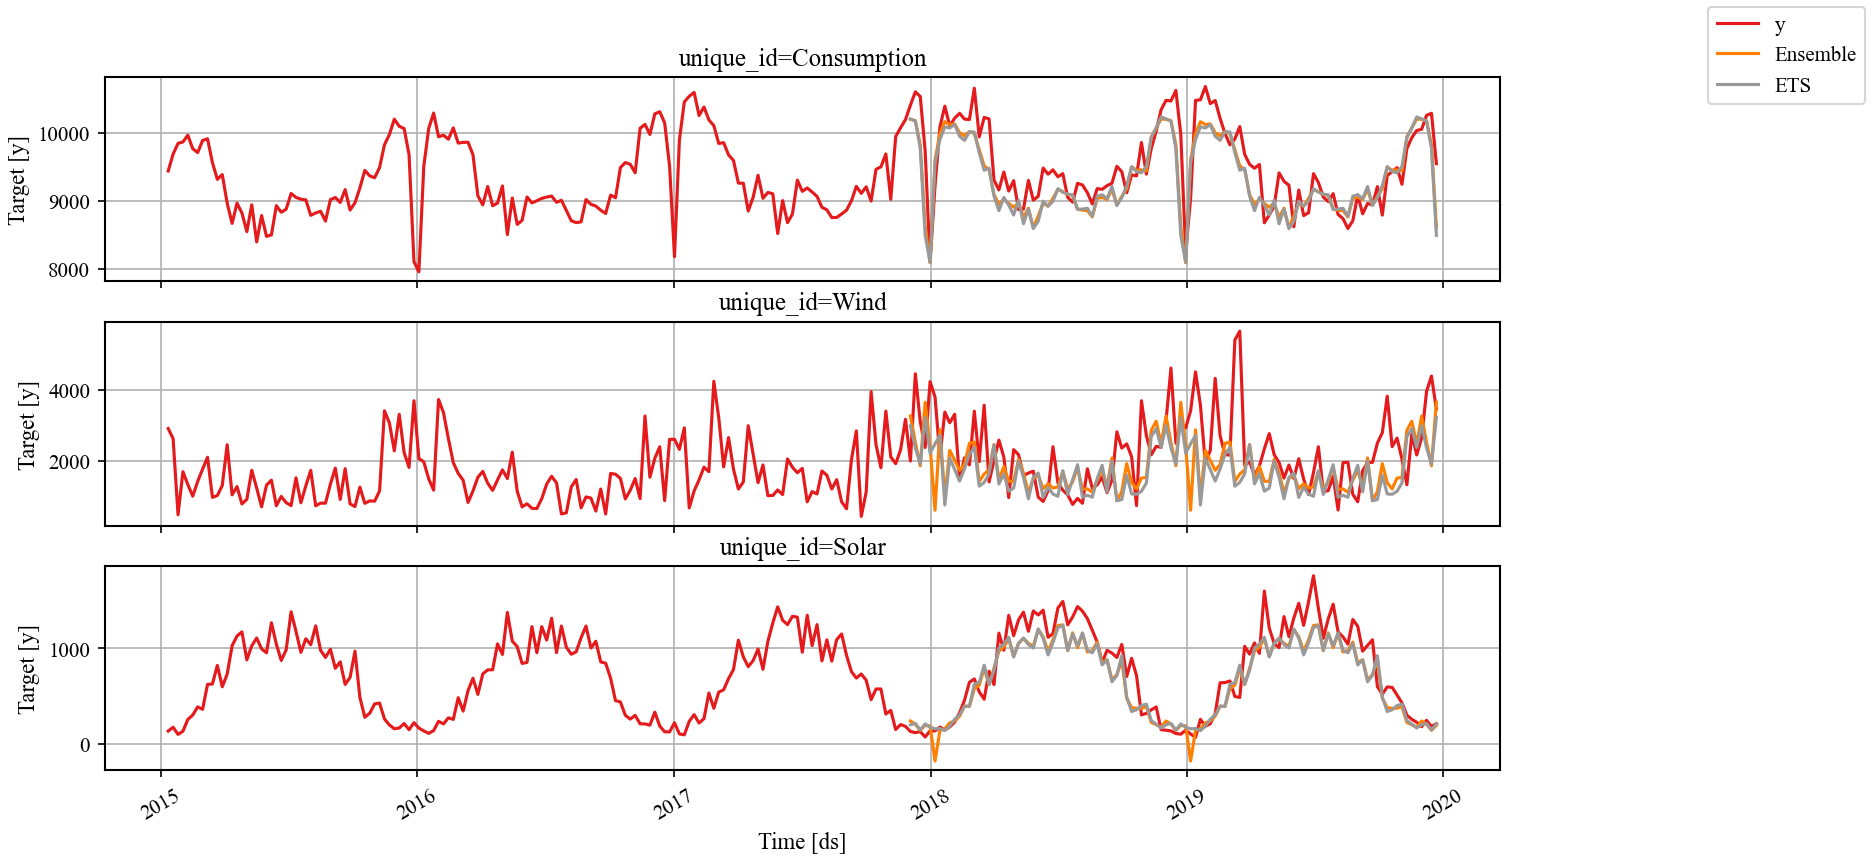

In [28]:
fcst_sf['Ensemble'] = fcst_sf[aliases].mean(axis=1)


# Объединяем с тестом
eval_sf = df_test.merge(fcst_sf, on=['unique_id', 'ds'])

# Визуализация
plot_series_v2(
    df_train,
    forecasts_df=eval_sf,
    models=['Ensemble',  aliases[0]],  # покажем сравнение
    # level=[90],
    palette='Set1',
)

##### Метрики

In [29]:
metrics_sf_models = evaluate(
    df=eval_sf,
    metrics=metrics[:3],
    train_df=df_train,
    # level=LEVELS[-1:],
).pivot(
    index='metric',
    columns='unique_id',
    values=[*aliases, 'Ensemble']
)
metrics_sf_models.style.format('{:.2f}')

Как и ожидалось пдобный ансамбль лучше худших, но не лучше лучшего

##### Добавим интревалы наивным образом

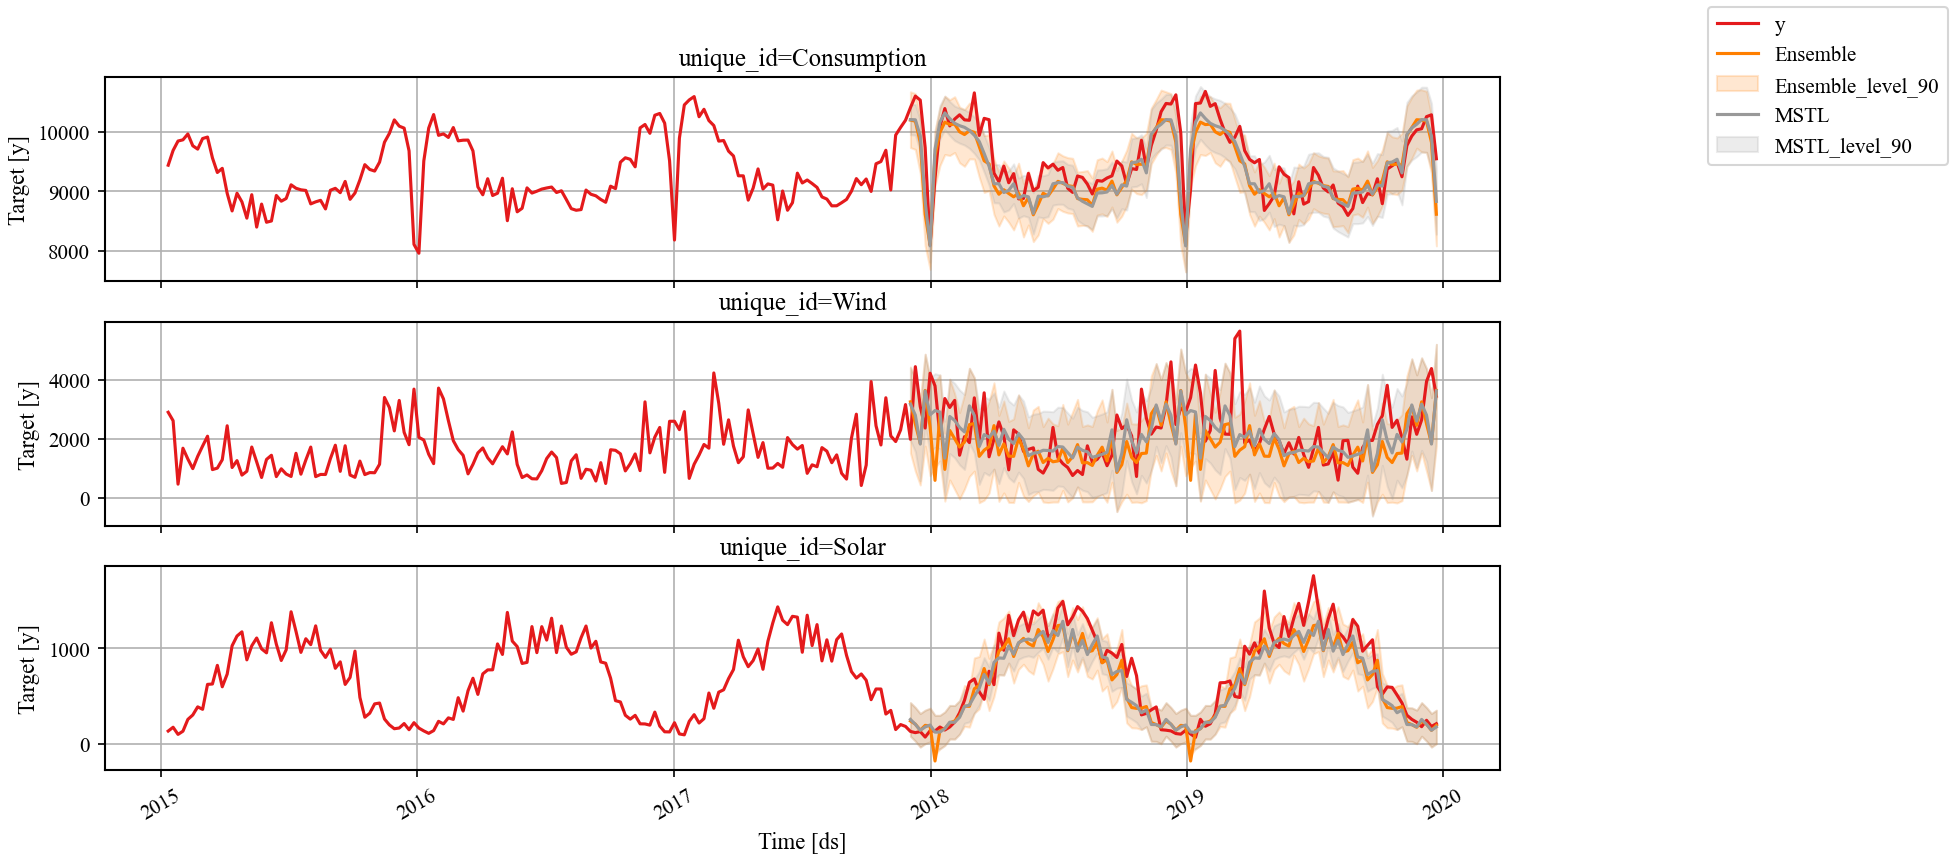

In [30]:
lvl  = LEVELS[:1][0]

lo_cols = [f"{name}-lo-{lvl}" for name in aliases if f"{name}-lo-{lvl}" in fcst_sf.columns]
hi_cols = [f"{name}-hi-{lvl}" for name in aliases if f"{name}-hi-{lvl}" in fcst_sf.columns]


fcst_sf[f'Ensemble-lo-{lvl}'] = fcst_sf[lo_cols].median(axis=1)
fcst_sf[f'Ensemble-hi-{lvl}'] = fcst_sf[hi_cols].median(axis=1)


eval_sf = df_test.merge(fcst_sf, on=['unique_id', 'ds'])
  
metrics_sf_models = evaluate(
    df=eval_sf,
    metrics=metrics,
    train_df=df_train,
    level=LEVELS[:1],
).pivot(
    index='metric',
    columns='unique_id',
    values=[*aliases, 'Ensemble']
)
display(metrics_sf_models.style.format('{:.2f}'))

plot_series_v2(
    df_train,
    forecasts_df=eval_sf,
    models=['Ensemble',  aliases[-1]],  # покажем сравнение
    level=LEVELS[:1],
    palette='Set1',
)

покрытие интервалов ведет себя точно также

#### Упражнение
1. проверить устойчивость ансамбля
2. проверить возможность добавления новых участников в ансамбль

### Взвешенный ансамбль

#### Квантильное взвешивание

Простое усреднение прогнозов не учитывает различия в качестве моделей и может ухудшать результат по сравнению с лучшей моделью (например, ARIMA показывала меньшую ошибку, чем невзвешенный ансамбль). Это связано с тем, что усреднение игнорирует вклад каждой модели в оценку неопределённости.

Одно из решений — использовать взвешенный ансамбль, где вес $ w_m $ модели $ m $ обратно пропорционален её ошибке. Наилучшей мерой ошибки для квантильных прогнозов является квантильный Loss.

Для квантиля уровня $ \alpha \in (0,1) $ вес модели определяется как:
$$
w_{m,\alpha} = \frac{1 / \left( \text{PL}_m(\alpha) + \varepsilon \right)}{\sum_{k=1}^M 1 / \left( \text{PL}_k(\alpha) + \varepsilon \right)},
$$
где $ \text{PL}_m(\alpha) = \frac{1}{N} \sum_{t=1}^N \ell_\alpha(y_t, \hat{q}_{t,\alpha}^{(m)}) $ — среднее значенвие квантильного Loss модели $ m $,  
$ \ell_\alpha(y, \hat{q}) = (y - \hat{q})(\alpha - \mathbb{I}\{y < \hat{q}\}) $ значенвие квантильного Loss модели $ m $ для квантиля $q$,  
а $ \varepsilon > 0 $ — малая константа для численной устойчивости.

Ансамблевый прогноз:
$$
\hat{q}_{t,\alpha}^{\text{ens}} = \sum_{m=1}^M w_{m,\alpha} \cdot \hat{q}_{t,\alpha}^{(m)}.
$$

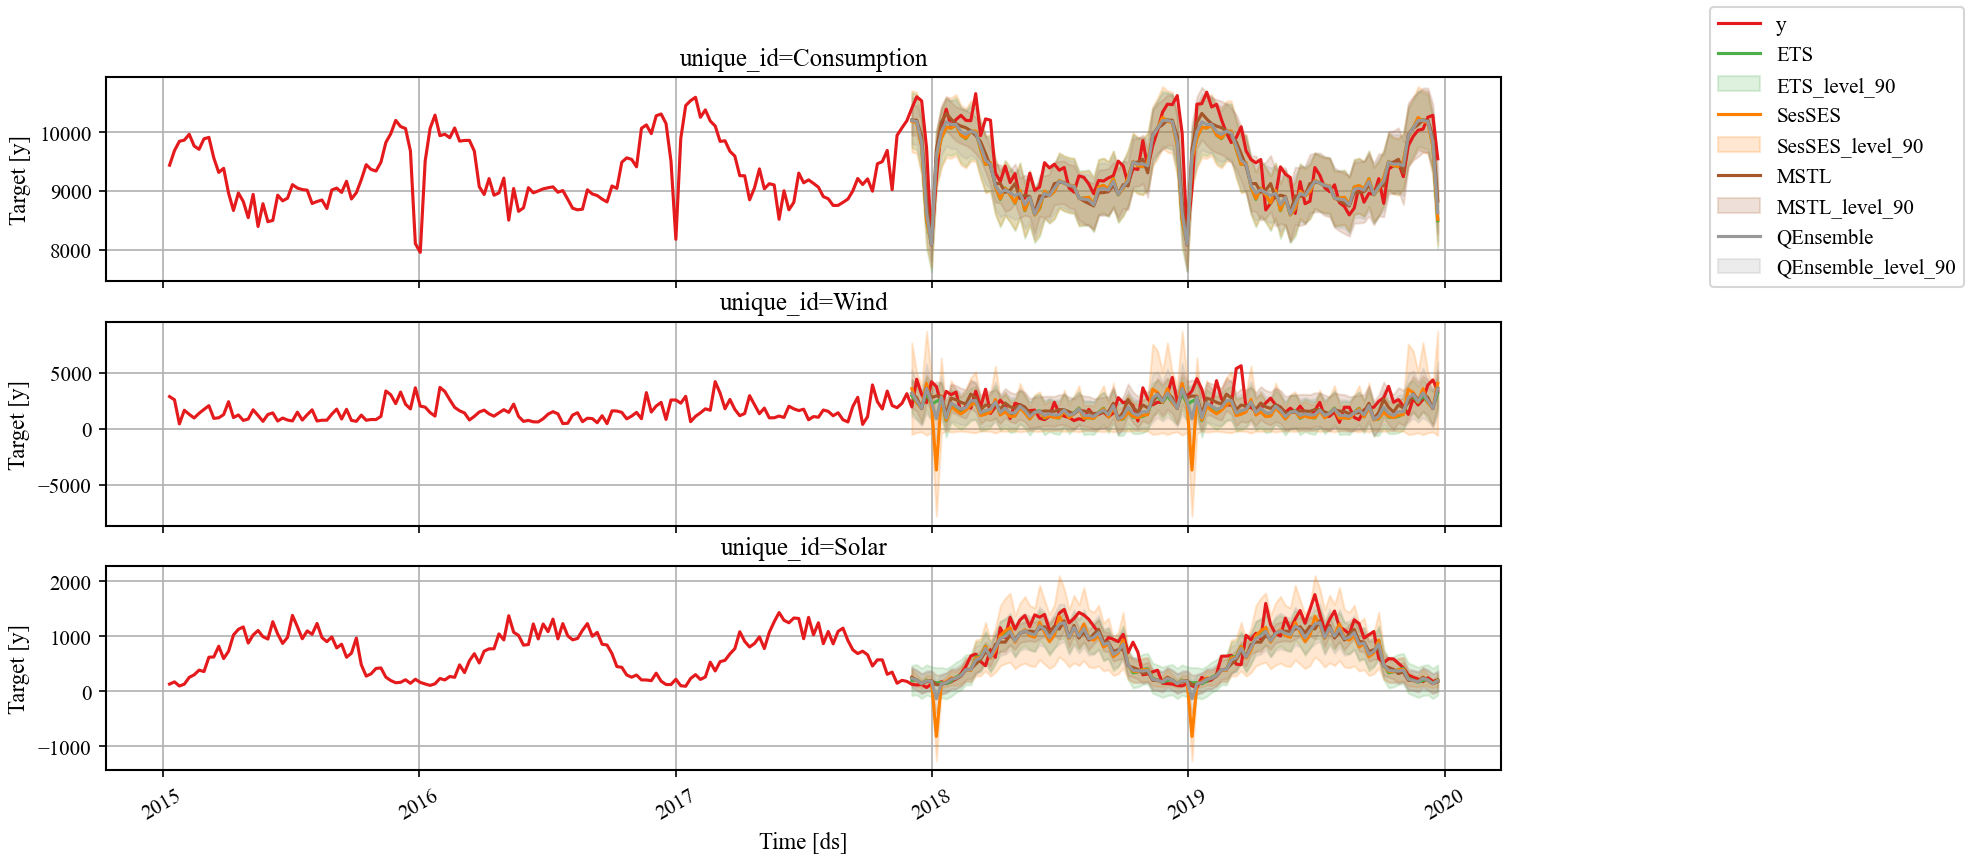

In [31]:
fcst_sf = sf.forecast(df=df_train, 
                      h=FH, 
                      level=LEVELS
                     )
eval_sf = df_test.merge(fcst_sf, on=['unique_id', 'ds'])

fcst_qensemble = quantile_ensemble_forecast(
    eval_df=eval_sf,
    model_names=aliases,
    levels=LEVELS,           
    target_col='y'
)
eval_sf = eval_sf.merge(fcst_qensemble, on=['unique_id', 'ds'])

metrics_sf_models = evaluate(
    df=eval_sf,
    metrics=metrics,
    train_df=df_train,
    level=LEVELS[:1],
).pivot(
    index='metric',
    columns='unique_id',
    values=[*aliases, 'QEnsemble']
)
display(metrics_sf_models.style.format('{:.2f}'))

plot_series_v2(
    df_train,
    forecasts_df=eval_sf,
    models=[*aliases,'QEnsemble'],
    level=LEVELS[:1],
    palette='Set1'
)

Полученный ансамбль слегка лучше.

#### Получим веса по метрикам

Можно построить ансамбли для различных метрик, которые мы используем. Получим их названия

In [32]:
metrics_df=evaluate(df=eval_sf, metrics=metrics, train_df=df_train, level=[90])
metrics_df['metric'].unique()

array(['mase', 'mae', 'rmse', 'smape', 'scaled_crps', 'coverage_level90',
       'scaled_quantile_loss_q0.05', 'scaled_quantile_loss_q0.95'],
      dtype=object)

Проверим, что для разных метрик разные веса

In [33]:
weight_dict = ensemble_weights_from_metrics(
    metrics_df=evaluate(df=eval_sf, metrics=metrics, train_df=df_train, level=LEVELS[:1]),
    aliases=aliases,
    metric_name = 'scaled_crps',
    per_series = False,
)
weight_dict

{'ETS': 0.34814946289900406,
 'SesSES': 0.27467597464191434,
 'MSTL': 0.3771745624590817}

#### Построение ансамбля с весами

In [34]:
weight_dict_ = {'ETS': 0.05,
               'SesSES': 0.05,
               'MSTL': 0.9}

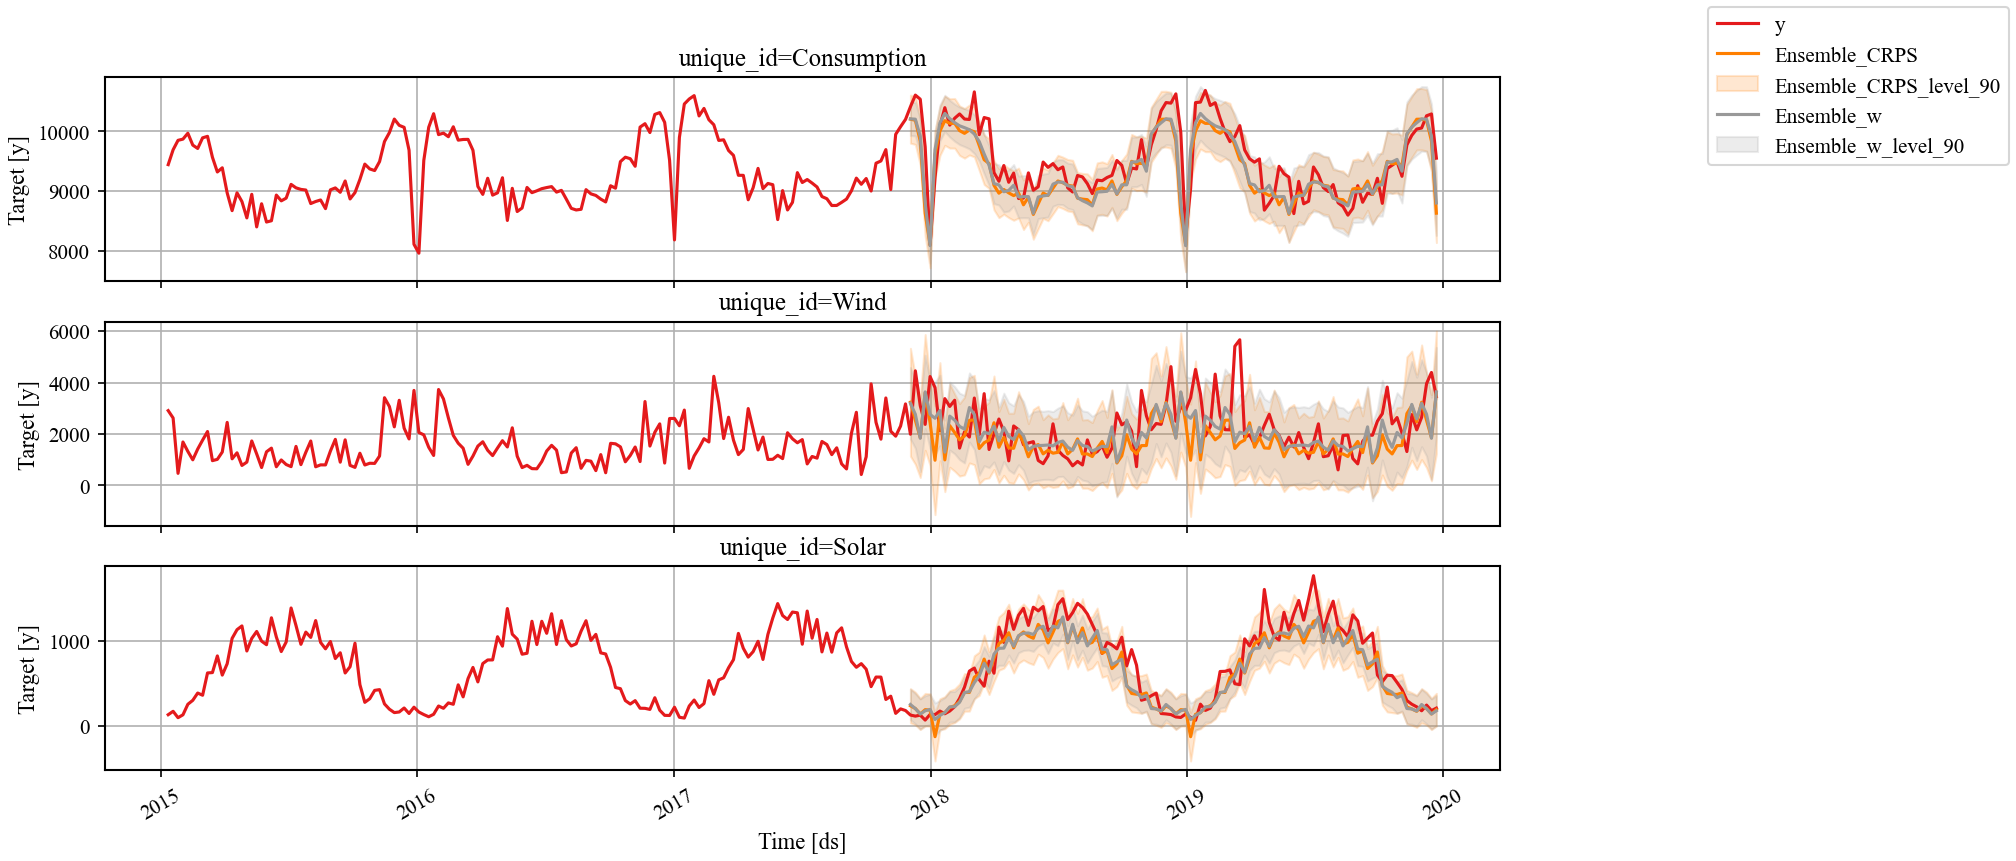

In [35]:
fcst_sf = sf.forecast(df=df_train, h=FH, level=LEVELS)
eval_sf = df_test.merge(fcst_sf, on=['unique_id', 'ds'])

fcst_ensemble_  = vanilla_ensemble(
    forecasts_df=fcst_sf,
    aliases=aliases,
    levels=LEVELS,
    weights = weight_dict,
    ensemble_name = 'Ensemble_CRPS',
)

eval_sf = eval_sf.merge(fcst_ensemble_, on=['unique_id', 'ds'])

fcst_ensemble_  = vanilla_ensemble(
    forecasts_df=fcst_sf,
    aliases=aliases,
    levels=LEVELS,
    weights = weight_dict_,
    ensemble_name = 'Ensemble_w',
)
eval_sf = eval_sf.merge(fcst_ensemble_, on=['unique_id', 'ds'])

evaluate_and_plot(df_train, df_test, eval_sf, metrics, levels=LEVELS[:1], model_names = ['Ensemble_CRPS','Ensemble_w' ], plot=True)

### Построение бустингов


#### Процедура Бустинга

- Базовая модель (слабя, например на тренд)

- Остатки на трейне = y − базовое in sample предсказание

- ETS/ARIMA прогноз остатков

- Объеденение прогонзов

- интервалы прогноза по остаткам или калибровкой

##### Предсказание тренда и сезонности, для этого целисообразно использовать процедуру MSTL

Тренд и сезонность, полученные в результате будетм считать условно детерминированными.

In [36]:
models = [
    # MSTL(season_length=SEASON, ),   
    AutoETS(season_length=SEASON, model='ZZA', damped=False)
]
alias =models[0].alias

aliases = [model.alias for model in models]
LEVELS  = [90, 95]

sf = StatsForecast(
    models=models,
    freq=FREQ,
)

fcst_sf = sf.forecast(df=df_train, 
                      h=FH, 
                      level=LEVELS,
                      fitted = True # для in_sample
                     )

##### вычисление остатков in_sample (`fitted = True`)

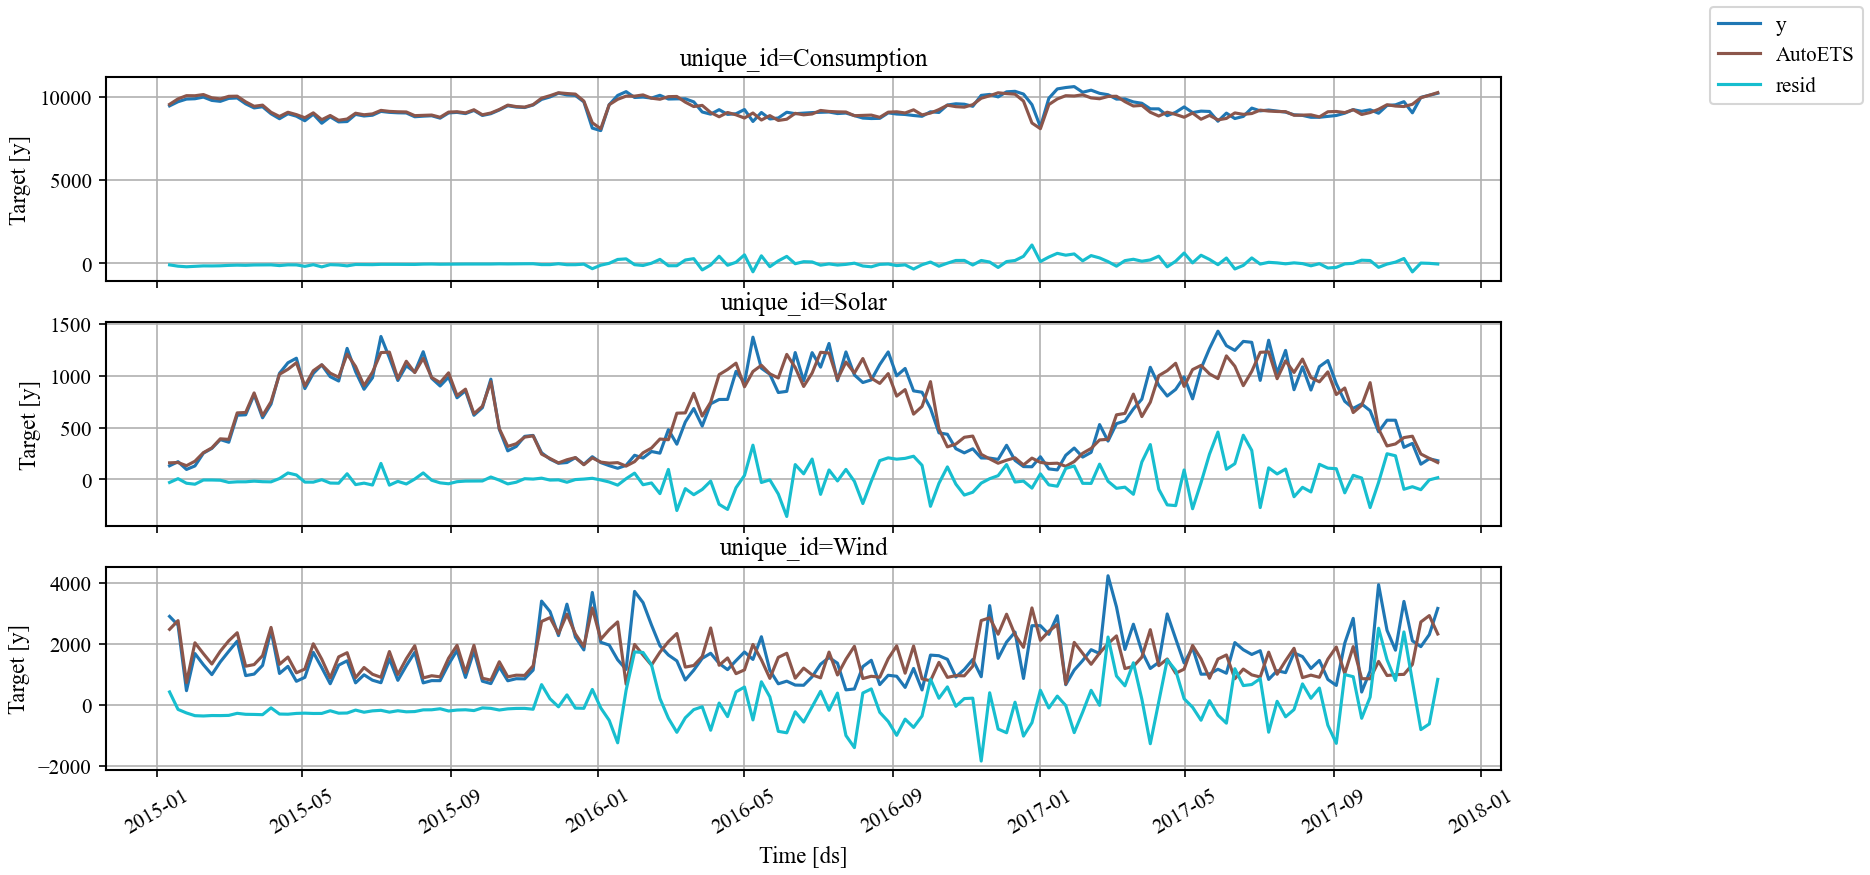

In [37]:
in_sample_sf = sf.forecast_fitted_values()
in_sample_sf['resid'] = in_sample_sf['y'] - in_sample_sf[alias]

plot_series_v2(forecasts_df=in_sample_sf)

##### предсказание остатков моделью ARIMA

In [38]:
resid_models = [
    AutoARIMA(season_length=SEASON),
]
resid_alias = resid_models[0].alias  # строка, например 'AutoARIMA'

sf_resid = StatsForecast(models=resid_models, freq=FREQ)
df_for_resid = in_sample_sf[['unique_id', 'ds', 'resid']].copy()

fcst_sf_resid = sf_resid.forecast(
    df=df_for_resid,
    h=FH,
    level=LEVELS,
    target_col='resid',
    fitted=True,
)

##### Формирование итогового предсказания.

Обратите внимание, тут неопределенность считается только по остаткам! так как мы решили, что тренд и сезон детерминированы.

На самом деле неопределнность нужно калибровать или считать более правильным спсосбом (через бутстреп неопределенности)

In [39]:
# --- Объединение прогноза и остатков (out-of-sample) ---
# После создания точечного прогноза:
fcst_sf[f'{alias}_r{resid_alias}'] = fcst_sf[alias] + fcst_sf_resid[resid_alias]

# Добавляем интервальные колонки:
for lvl in LEVELS:
    fcst_sf[f'{alias}_r{resid_alias}-lo-{lvl}'] = fcst_sf[alias] + fcst_sf_resid[f'{resid_alias}-lo-{lvl}']
    fcst_sf[f'{alias}_r{resid_alias}-hi-{lvl}'] = fcst_sf[alias] + fcst_sf_resid[f'{resid_alias}-hi-{lvl}']

# Аналогично для in_sample:
in_sample_sf_resid = sf_resid.forecast_fitted_values()
in_sample_sf[f'{alias}_r{resid_alias}'] = in_sample_sf[alias] + in_sample_sf_resid[resid_alias]

# Если нужны интервалы для in_sample, проделайте то же самое:
for lvl in LEVELS:
    in_sample_sf[f'{alias}_r{resid_alias}-lo-{lvl}'] = in_sample_sf[alias] + in_sample_sf_resid[f'{resid_alias}-lo-{lvl}']
    in_sample_sf[f'{alias}_r{resid_alias}-hi-{lvl}'] = in_sample_sf[alias] + in_sample_sf_resid[f'{resid_alias}-hi-{lvl}']

##### Метрики

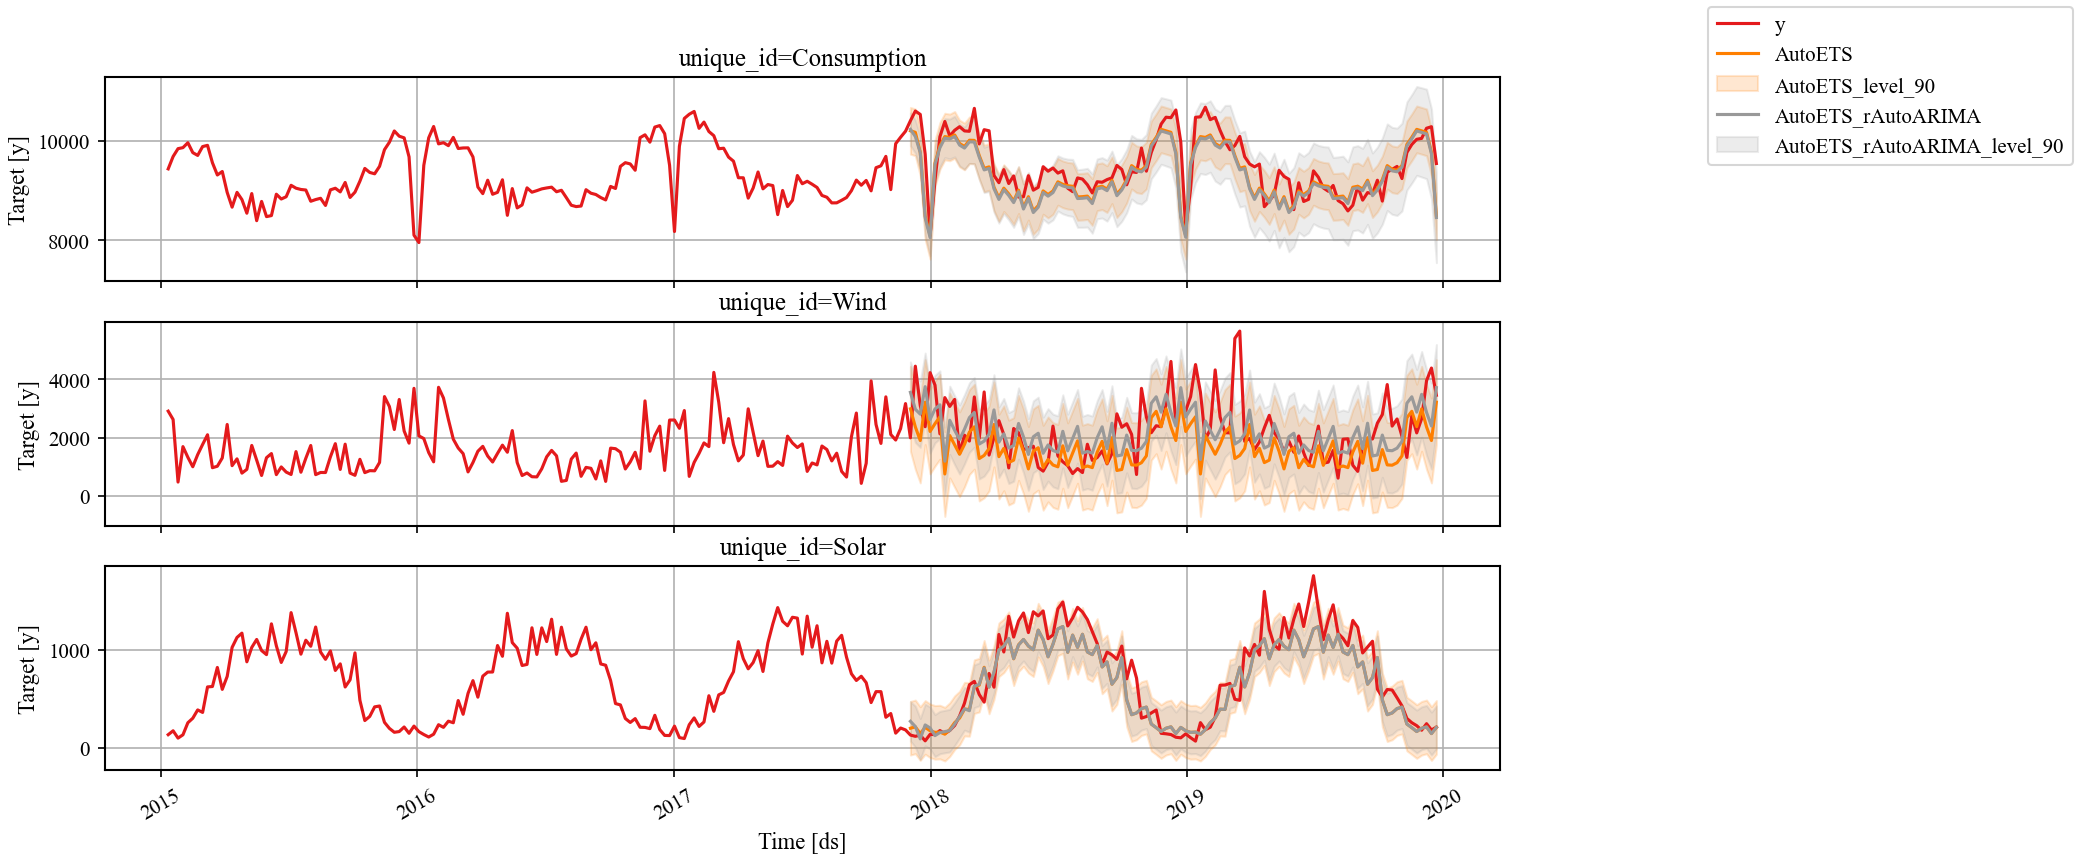

In [40]:
evaluate_and_plot(df_train, df_test, fcst_sf, metrics, levels=LEVELS[:1], model_names = None, plot=True)

Полученная модель работает чуть лучше в сложном случае - винд


### Дополнительно: создание экзогенных регрессоров инородной моделью

Кроме использования параллельных ан ансамблей и последовательных также можно воспользоваться предсказаниями одной модели в качестве будущих регрессоров для другой модели. Канонический пример такого тюнинга - [neuralprophet](https://neuralprophet.com/). Модель в том числе использует авторегрессионные предсказания в качестве экзогенных переменных.  

Другим интересным примером применения регрессоров может быть идея ARIMAProphet - [использование сезонного моделирования Prophet](https://otexts.com/fpppy/nbs/12-advanced.html#sec-prophet) в качестве экзогенных переменных для моделей SARIMAX. 

> Также важно отметить, что nixtla предлагает альтернативный [сценарий экспериментов с AutoARIMAProphet](https://github.com/Nixtla/statsforecast/tree/main/experiments/arima_prophet_adapter). Однако, сценарий работает только для базовых операций.

In [41]:
from prophet_adapter import ARIMAProphet

models = [ARIMAProphet( order=(3, 1, 1),
    seasonal_order=(1, 1, 0),
    season_length=SEASON,
    freq = FREQ,
    yearly_seasonality = 12, 
    country_holidays = 'GE', ),
         ]
sf = StatsForecast(models=models, freq=FREQ, n_jobs=1)

fcst_sf = sf.forecast(df=df_train, h=FH, level = LEVELS, fitted=True)

eval_sf = df_test.merge(fcst_sf, on=['unique_id', 'ds'])

NameError: name 'ConformalIntervals' is not defined

## Дополнительно

In [83]:
from statsforecast.adapters.prophet import AutoARIMAProphet

In [96]:
def forecast_with_arimaprophet(forecaster, df_train, periods=FH, freq=FREQ):
    results_list = []

    for (name, y_train), (name, y_test) in zip(df_train.groupby('unique_id'), df_test.groupby('unique_id')):
        m = AutoARIMAProphet()
        m.add_seasonality(name="yearly", period=SEASON, fourier_order=5)
        m.fit(y_train)
        future = m.make_future_dataframe(periods=FH, freq=FREQ)
        y_pred = m.predict(future)

        # Преобразуем в нужный формат, убедившись, что yhat — одномерный
        temp_df = pd.DataFrame({
            'unique_id': [name] * len(y_pred),
            'ds': y_pred.index,
            'Prophet': y_pred['yhat'].values.flatten(),  # flatten() гарантирует 1D
            'Prophet-lo-90': y_pred['yhat_lower'].values.flatten(),  
            'Prophet-hi-90': y_pred['yhat_upper'].values.flatten(),})    
        results_list.append(temp_df)

    fcst_sf = pd.concat(results_list, ignore_index=True)
    return fcst_sf

In [97]:
m = AutoARIMAProphet()
m.add_seasonality(name="yearly", period=SEASON, fourier_order=5)

fcst_sf = forecast_with_arimaprophet(m, df_train, periods=FH,)



In [99]:
eval_sf = df_test.merge(fcst_sf, on=['unique_id', 'ds'])

alias = [x for x in fcst_sf.columns if not x in base_cols]

n_rows = eval_sf['unique_id'].nunique()
fig, ax = plt.subplots(n_rows, 1, figsize=(12, 2*n_rows), sharex=True)

plot_series(
    df_train,
    forecasts_df = eval_sf,
    ax=ax,
    max_insample_length = SEASON,
    palette='Set1',
)


ValueError: You are trying to merge on datetime64[ns] and int64 columns for key 'ds'. If you wish to proceed you should use pd.concat

## Обнаружение аномальных данных

In [ ]:
models = [
    AutoETS(season_length=SEASON, model='ZZA', damped = False, alias='ETS'),
    MSTL(season_length=SEASON, ),
    # TBATS(SEASON, use_trend = True, use_damped_trend = True),
    ARIMA(order=(3, 1, 1),
                season_length = SEASON,
                seasonal_order = (0, 1, 1,)  )
    
]
aliases = [model.alias for model in models]
LEVELS = [95, 99]

sf = StatsForecast(
    models=models,
    freq=FREQ,
)

fcst_sf = sf.forecast(df=df_train, 
                      h=FH, 
                      level=LEVELS,
                      fitted=True
                     )
eval_sf = df_test.merge(fcst_sf, on=['unique_id', 'ds'])

plot_series_v2(
    df_train,
    forecasts_df = eval_sf,
    level=LEVELS[-1:],
    palette='Set1',
)

In [ ]:
insample_forecasts = sf.forecast_fitted_values()
# insample_forecasts.head()

In [ ]:
anomalies = insample_forecasts[~insample_forecasts['y'].between(insample_forecasts['MSTL-lo-99'], insample_forecasts['MSTL-hi-99'])]
# anomalies.head()

In [ ]:
plot_series(forecasts_df=insample_forecasts,
            models = ['ARIMA'],
            level=LEVELS, 
            plot_anomalies=True)

## ДОПОЛНИТЕЛЬНО

### некоторые аугментации искажением

In [ ]:
df_addtitive_shock = add_additive_shock(
    df_train,
    shock_date='2015-03-01',
    shock_strength=1.5,   # 1.5 * IQR — сильный шок
    recovery_offset='12W',   # 12 недель восстановления
    freq=FREQ
)

In [ ]:
n_rows = df_train['unique_id'].nunique()
fig, ax = plt.subplots(n_rows, 1, figsize=(12, 2*n_rows), sharex=True)

plot_series(forecasts_df=df_addtitive_shock, 
            ax = ax,
            palette='tab10')

In [ ]:
df_result = add_seasonal_imbalance_by_quantile(
    df_train,
    target_seasonal_phases=list(range(20,32)),   # летние недели
    season_length=SEASON,
    imbalance_percent=45.0,
    direction='reduce',
    start_date='2015-01-01',
    duration_offset='2Y', 
    freq=FREQ
)

In [ ]:
n_rows = df_train['unique_id'].nunique()
fig, ax = plt.subplots(n_rows, 1, figsize=(12, 2*n_rows), sharex=True)

plot_series(forecasts_df=df_result, 
            ax = ax,
            palette='tab10')

In [ ]:
df_result = add_local_volatility_spike(
    df_train,
    spike_start='2015-04-01',
    duration_offset='16W',
    noise_percent=50.0,
    freq=FREQ
)

In [ ]:
n_rows = df_train['unique_id'].nunique()
fig, ax = plt.subplots(n_rows, 1, figsize=(12, 2*n_rows), sharex=True)

plot_series(forecasts_df=df_result, 
            ax = ax,
            palette='tab10')

In [ ]:
df_result =  add_asymmetric_shock(
    df_train,
    shock_start='2015-03-01',
    recovery_offset='12W',
     drop_percent=40.0,
    freq=FREQ
)

In [ ]:
n_rows = df_train['unique_id'].nunique()
fig, ax = plt.subplots(n_rows, 1, figsize=(12, 2*n_rows), sharex=True)

plot_series(forecasts_df=df_result, 
            ax = ax,
            palette='tab10')

In [ ]:
df_result = add_signal_degradation(
    df_train,
    degradation_start='2015-01-01',
    duration_offset='52W',      # ← offset-строка вместо weeks
    final_snr_ratio=0.1,
    freq=FREQ,                  # ← обязательная частота
)

In [ ]:
n_rows = df_train['unique_id'].nunique()
fig, ax = plt.subplots(n_rows, 1, figsize=(12, 2*n_rows), sharex=True)

plot_series(forecasts_df=df_result, 
            ax = ax,
            palette='tab10')

In [ ]:
df_result = add_seasonal_phase_shift(
    df_train,
    phase_shift_steps=4,
    season_length=SEASON,          # используется только для документации
    start_date='2015-01-01',
    duration_offset='1Y',
    freq=FREQ
)

In [ ]:
n_rows = df_train['unique_id'].nunique()
fig, ax = plt.subplots(n_rows, 1, figsize=(12, 2*n_rows), sharex=True)

plot_series(forecasts_df=df_result, 
            ax = ax,
            palette='tab10')

In [ ]:
df_result = add_trend_break(
    df_train,
    break_date='2016-01-01',
    trend_change_per_step=-33.5,
    duration_offset='1Y',
    freq=FREQ
)

In [ ]:
n_rows = df_train['unique_id'].nunique()
fig, ax = plt.subplots(n_rows, 1, figsize=(12, 2*n_rows), sharex=True)

plot_series(forecasts_df=df_result, 
            ax = ax,
            palette='tab10')

In [ ]:
holidays = [
    '2016-10-24', '2016-10-25', '2016-10-26',
    '2017-10-24', '2017-10-25', '2017-10-26',
    '2018-10-24', '2018-10-25', '2018-10-26',
    '2019-10-24', '2019-10-25', '2019-10-26',
]

df_result = add_seasonal_regressors_effect(
    df_train,
    event_dates=holidays,
    effect_percent=65.0,
    direction='spike',        # снижение активности
    window_radius=4,        # включая день до и после
    freq=FREQ,
    reference='pre_event'
)

In [ ]:
n_rows = df_train['unique_id'].nunique()
fig, ax = plt.subplots(n_rows, 1, figsize=(12, 2*n_rows), sharex=True)

plot_series(forecasts_df=df_result, 
            ax = ax,
            palette='tab10')

In [ ]:
df_result = add_sensor_drift(
    df_train,
    drift_start='2016-01-01',
    duration_offset='1Y',
    drift_percent=65.0,
    profile='saturation',
    freq=FREQ
)

In [ ]:
n_rows = df_train['unique_id'].nunique()
fig, ax = plt.subplots(n_rows, 1, figsize=(12, 2*n_rows), sharex=True)

plot_series(forecasts_df=df_result, 
            ax = ax,
            palette='tab10')

In [ ]:
# df_result = add_distribution_shift(df_train, 
#                                 shift_start='2016-04-01', 
#                                 shift_percent=35.0, 
#                                 stat='median', 
#                                 freq=FREQ)

In [ ]:
# n_rows = df_train['unique_id'].nunique()
# fig, ax = plt.subplots(n_rows, 1, figsize=(12, 2*n_rows), sharex=True)

# plot_series(forecasts_df=df_result, 
#             ax = ax,
#             palette='tab10')

In [ ]:
df_result = add_variance_expansion(df_train, 
                                expansion_start='2016-04-01', 
                                   duration_offset='1Y',
                                expansion_factor=2.5,
                                freq=FREQ)

In [ ]:
n_rows = df_train['unique_id'].nunique()
fig, ax = plt.subplots(n_rows, 1, figsize=(12, 2*n_rows), sharex=True)

plot_series(forecasts_df=df_result, 
            ax = ax,
            palette='tab10')

In [ ]:
df_result = add_skewness_shift(df_train, 
                                skew_start='2016-04-01', 
                                   duration_offset='1Y',
tail='right',              # 'right' или 'left'
    intensity=2.3,             # сила искажения (0–1)
                                freq=FREQ)

In [ ]:
n_rows = df_train['unique_id'].nunique()
fig, ax = plt.subplots(n_rows, 1, figsize=(12, 2*n_rows), sharex=True)

plot_series(forecasts_df=df_result, 
            ax = ax,
            palette='tab10')

In [ ]:
import session_info
session_info.show(html=False)